# Tennis Betting Model

## Load and Clean Data

### Import Libraries

In [5]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split

### Load Data

In [6]:
def get_df_from_folder(folder_path):

    # Create empty list for dfs 
    dfs = []

    # Iterate through files in folder
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        df = pd.read_excel(file_path)
        dfs.append(df)

    # Concatenate into one dataframe
    df = pd.concat(dfs)

    # Reset index
    df = df.reset_index(drop=True)

    return df


We can extract only the relevant columns:

In [8]:
# Get folder path
folder_path = 'match_datasets_wta/'

# Run above function to get dataframe
df = get_df_from_folder(folder_path)

c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [9]:
def create_winner_loser_dfs(df):

    # Extract necessary columns
    df2 = df[['Date', 'Winner', 'Loser','WRank', 'LRank', 'WPts', 'LPts', 'Wsets',
        'Lsets', 'MaxW', 'MaxL']]
    
    # Create copies for winners and losers
    df_winners = df2.copy()
    df_losers = df2.copy()

    # Drop odds columns for opposite outcome
    df_winners = df_winners.drop('MaxL', axis=1)
    df_losers = df_losers.drop('MaxW', axis=1)

    # Create addtional feature based on rank difference:
    df_winners['rank_diff'] = df_winners['WRank'] - df_winners['LRank']
    df_losers['rank_diff'] = df_losers['LRank'] - df_losers['WRank']

    # Create addtional feature based on point difference:
    df_losers['pts_diff'] = df_losers['LPts'] - df_losers['WPts']
    df_winners['pts_diff'] = df_winners['WPts'] - df_winners['LPts']

    # Create a column for whether the player won the match 
    # which will ultimately be our target variable:
    df_winners['won'] = 1
    df_losers['won'] = 0

    # Next we can create features based on a 'score' value where a score is positive or negative 
    # based on whether a player won the match, and inversely proportional to the rank or points 
    # difference between competitors (i.e. a player will receive a lower score for beating a 
    # competitor with a lower rank when compared to beating a competitor with a higher rank)

    # Get lowest rank and highest points
    lowest_rank = df[['WRank', 'LRank']].max().max()
    highest_pts = df[['WPts', 'LPts']].max().max()

    # Create scores based on wins and rank/points
    df_winners['rank_score'] = -df_winners['rank_diff'] + lowest_rank
    df_losers['rank_score'] = -df_losers['rank_diff'] - lowest_rank

    df_winners['pts_score'] = -df_winners['pts_diff'] + highest_pts
    df_losers['pts_score'] = -df_losers['pts_diff'] - highest_pts

    # We can also create similar scores for when players have won in straight sets:
        
    # Straight sets column
    df_winners['straight_sets'] = np.where(df_winners['Lsets'] == 0, 1, 0)
    df_losers['straight_sets'] = np.where(df_losers['Lsets'] == 0, -1, 0)

    # Create scores based on straight sets and rank/points
    df_winners['ss_rank_score'] = np.where(df_winners['straight_sets'] == 1, -df_winners['rank_diff'] + lowest_rank, 0)
    df_losers['ss_rank_score'] = np.where(df_losers['straight_sets'] == -1, -df_losers['rank_diff'] - lowest_rank, 0)

    df_winners['ss_pts_score'] = np.where(df_winners['straight_sets'] == 1, -df_winners['pts_diff'] + lowest_rank, 0)
    df_losers['ss_pts_score'] = np.where(df_losers['straight_sets'] == -1, -df_losers['pts_diff'] - lowest_rank, 0)    

    # Drop columns
    df_winners = df_winners.drop(['Loser','WRank','LRank','WPts','LPts','Wsets','Lsets'], axis=1)
    df_losers = df_losers.drop(['Winner','WRank','LRank','WPts','LPts','Wsets','Lsets'], axis=1)

    # Rename player, odds and date column
    df_winners = df_winners.rename(columns={'Winner':'player', 'Date':'date', 'MaxW': 'odds'})
    df_losers = df_losers.rename(columns={'Loser':'player', 'Date':'date', 'MaxL': 'odds'})

    return df_winners, df_losers

In [10]:
# Run above function
df_winners, df_losers = create_winner_loser_dfs(df)

We can create a function to conbine these dataframes:

In [11]:
def combine_winners_losers_dfs(df_winners, df_losers):

    # Combine dataframes
    match_df = pd.concat([df_winners, df_losers])

    # Sort by player and date
    match_df = match_df.sort_values(by=['player', 'date'])

    # Reset Index
    match_df = match_df.reset_index(drop=True)

    return match_df

In [12]:
# Run above function 
match_df = combine_winners_losers_dfs(df_winners, df_losers) 

Now we can create a function to add addtional features for each match showing the results for each the prior ten matches to each match: 

In [13]:
def create_prior_match_features(df): 
    
    # Features to add for previous match
    features = ['rank_score', 'pts_score','ss_rank_score', 'ss_pts_score']

    # Iterate over unique players
    for player in df['player'].unique():
        # Filter dataframe for each player
        player_matches = df[df['player'] == player]

        # Shift the features
        previous_features = player_matches[features].shift(1)

        # Iterate over number of previous matches
        for i in range(1, 11):
            for feature in features:
                df.loc[player_matches.index, f'{feature}_{i}_match_ago'] = previous_features[feature]
            previous_features = previous_features.shift(1)

    # Drop all matches without ten previous matches to show stats for
    df = df.dropna()

    return df


In [14]:
# Run above function
match_df = create_prior_match_features(match_df)

We can create a function to extract an odds dataframe from our original dataframe:

In [15]:
def extract_odds_df(df):

    # Extract columns
    odds_col = df.iloc[:,2]
    won_col = df.iloc[:,5]

    # Create dataframe
    odds_win_df = pd.concat([odds_col, won_col], axis=1)

    return odds_win_df

In [16]:
# Run above function
odds_win_df = extract_odds_df(match_df)

In [17]:
odds_win_df

,odds,won
10,2.95,1
11,2.00,0
12,1.54,1
13,6.30,0
14,1.83,1
...,...,...
46541,3.14,0
46542,3.57,0
46543,1.68,1
46544,2.23,1


We can now creat a function to engineer additional features summing the scores from the previous 3, 5 and 10 matches:

In [18]:
def create_prior_score_features(df):

    # Drop odds columns
    df = df.drop(columns='odds')

    # Calculate sums of rank scores
    df['rank_score_past3'] = df.iloc[:,10:19:4].sum(axis=1)
    df['rank_score_past5'] = df.iloc[:,10:29:4].sum(axis=1)
    df['rank_score_past10'] = df.iloc[:,10:49:4].sum(axis=1)

    # Calculate sums of points scores
    df['pts_score_past3'] = df.iloc[:,11:20:4].sum(axis=1)
    df['pts_score_past5'] = df.iloc[:,11:30:4].sum(axis=1)
    df['pts_score_past10'] = df.iloc[:,11:49:4].sum(axis=1)
    
    # Calculate sums of rank scores - straight sets
    df['ss_rank_score_past3'] = df.iloc[:, 12:21:4].sum(axis=1)
    df['ss_rank_score_past5'] = df.iloc[:, 12:31:4].sum(axis=1)
    df['ss_rank_score_past10'] = df.iloc[:, 12:49:4].sum(axis=1)

    # Calculate sums of points scores - straight sets
    df['ss_pts_score_past3'] = df.iloc[:, 13:22:4].sum(axis=1)
    df['ss_pts_score_past5'] = df.iloc[:, 13:30:4].sum(axis=1)
    df['ss_pts_score_past10'] = df.iloc[:, 13:50:4].sum(axis=1)

    # Drop unnecessary columns
    df = df.drop(df.columns[4:50], axis=1)
    df = df.drop(df.columns[0:2], axis=1)

    return df


In [19]:
# Run above function 
match_df = create_prior_score_features(match_df)

Finally we can create a functiont to train/test split our dataframes on the same indexes:

In [20]:
def create_train_test_splits(match_df, odds_win_df):

    # Retrieve indexes
    indexes = match_df.index

    # Train/test split indexes
    train_indexes, test_indexes = train_test_split(
        indexes, test_size=0.3, random_state=42
    )

    # Define X_train and X_test
    X_train = match_df.loc[train_indexes]
    X_test = match_df.loc[test_indexes]

    # Define odds_win_train and odds_win_test
    odds_win_train = odds_win_df.loc[train_indexes]
    odds_win_test = odds_win_df.loc[test_indexes]

    return X_train, X_test, odds_win_train, odds_win_test   

In [21]:
# Run above function
X_train, X_test, odds_win_train, odds_win_test = create_train_test_splits(match_df, odds_win_df)

We can save these dataframes to files:

In [22]:
X_train.to_csv(r'train_test_datasets\X_train.csv', index=False)
X_test.to_csv(r'train_test_datasets\X_test.csv', index=False)
odds_win_train.to_csv(r'train_test_datasets\odds_win_train.csv', index=False)
odds_win_test.to_csv(r'train_test_datasets\odds_win_test.csv', index=False)

## Model Building

### Import Libraries

In [23]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import optuna

c:\Users\samke\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First we load our datasets:

In [24]:
X_train = pd.read_csv(r'train_test_datasets\X_train.csv')
X_test = pd.read_csv(r'train_test_datasets\X_test.csv')
odds_win_train = pd.read_csv(r'train_test_datasets\odds_win_train.csv')
odds_win_test = pd.read_csv(r'train_test_datasets\odds_win_test.csv')

We can define y_train and y_test by dropping our odds columns:

In [25]:
# Extract win columns
y_train = odds_win_train['won']
y_test = odds_win_test['won']

Now we can use Optuna to tune different models and see which performs best:

Random Forest:

In [26]:
# Define objective function for hyperparameter optimisation
def objective(trial):
    # Define hyperparameters to be optimized
    param = {
        'n_estimators' : trial.suggest_int('n_estimators', 50, 100),
        'max_depth' : trial.suggest_int('max_depth', 2, 10),
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 5)
    }
    
    # Create an XGBoost regressor model with the given hyperparameters
    rf = RandomForestClassifier(**param)

    # Compute cross-validation scores
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')

    # Calculate the mean auc score across cross-validation folds
    return scores.mean()

# Create an Optuna study and run the trials
study2 = optuna.create_study(direction='maximize') 
study2.optimize(objective, n_trials=100)

[I 2023-06-29 15:39:29,140] A new study created in memory with name: no-name-b64acccf-90b9-40a9-8c57-1b947adca1bc
[I 2023-06-29 15:39:43,377] Trial 0 finished with value: 0.6852297374687806 and parameters: {'n_estimators': 65, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.6852297374687806.
[I 2023-06-29 15:39:48,846] Trial 1 finished with value: 0.6704208990497535 and parameters: {'n_estimators': 77, 'max_depth': 2, 'min_samples_split': 7, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.6852297374687806.
[I 2023-06-29 15:40:04,750] Trial 2 finished with value: 0.685782494066776 and parameters: {'n_estimators': 76, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 2 with value: 0.685782494066776.
[I 2023-06-29 15:40:29,329] Trial 3 finished with value: 0.6860241041497901 and parameters: {'n_estimators': 90, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 4}. Best is trial 3 with value: 0.686024

In [27]:
# Define random forest regressor with optimised hyperparameters
rf = RandomForestClassifier(n_estimators=study2.best_params['n_estimators'],
                            max_depth=study2.best_params['max_depth'],
                            min_samples_split=study2.best_params['min_samples_split'],
                            min_samples_leaf=study2.best_params['min_samples_leaf'],
                            random_state=42)

# Fit the regressor with the training data
rf.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf.predict(X_test)

# Evaluate the performance of the model using auc
auc_rf = roc_auc_score(y_test, y_pred_rf)

XGBoost:

In [28]:
# Define objective function for hyperparameter optimisation
def objective(trial):

    # Define hyperparameters to be optimised
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 100),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42
    }


    # Create an XGBoost regressor model with the given hyperparameters
    xg = XGBClassifier(**param)

    # Compute cross-validation scores
    scores = cross_val_score(xg, X_train, y_train, cv=5, scoring='roc_auc')

    # Calculate the mean auc score across cross-validation folds
    return scores.mean()

# Create an Optuna study and run the trials
study3 = optuna.create_study(direction='maximize') 
study3.optimize(objective, n_trials=100)

[I 2023-06-29 16:19:43,185] A new study created in memory with name: no-name-58df8f5d-abd7-4a4d-a5b9-869644c08def
[I 2023-06-29 16:19:49,750] Trial 0 finished with value: 0.6779100247082253 and parameters: {'n_estimators': 77, 'max_depth': 10, 'learning_rate': 0.054160597127082995, 'subsample': 0.6996010623883111, 'colsample_bytree': 0.5322883842194407, 'min_child_weight': 8}. Best is trial 0 with value: 0.6779100247082253.
[I 2023-06-29 16:19:54,176] Trial 1 finished with value: 0.6864309278395921 and parameters: {'n_estimators': 76, 'max_depth': 4, 'learning_rate': 0.05878982347765372, 'subsample': 0.8704147148763526, 'colsample_bytree': 0.9108590912206309, 'min_child_weight': 7}. Best is trial 1 with value: 0.6864309278395921.
[I 2023-06-29 16:19:58,954] Trial 2 finished with value: 0.6856199378267543 and parameters: {'n_estimators': 86, 'max_depth': 4, 'learning_rate': 0.07385818921204294, 'subsample': 0.8558389627868945, 'colsample_bytree': 0.9067778596138278, 'min_child_weight': 

In [29]:
# Define random forest regressor with optimized hyperparameters
xg = XGBClassifier(
                            n_estimators = study3.best_params['n_estimators'],
                            max_depth = study3.best_params['max_depth'],
                            learning_rate = study3.best_params['learning_rate'],
                            subsample = study3.best_params['subsample'],
                            colsample_bytree = study3.best_params['colsample_bytree'],
                            min_child_weight = study3.best_params['min_child_weight'],
                            random_state=42
)

# Fit the regressor with the training data
xg.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xg = xg.predict(X_test)

# Evaluate the performance of the model using auc
auc_xg = roc_auc_score(y_test, y_pred_xg)


Catboost:

In [30]:
# Define objective function for hyperparameter optimisation
def objective(trial):

    # Define hyperparameters to be optimised
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 100),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_state': 42,
        'verbose': False
    }

    # Create a CatBoost regressor model with the given hyperparameters
    cb = CatBoostClassifier(**param)

    # Compute cross-validation scores
    scores = cross_val_score(cb, X_train, y_train, cv=5, scoring='roc_auc')

    # Calculate the mean auc score across cross-validation folds
    return scores.mean()

# Create an Optuna study and run the trials
study4 = optuna.create_study(direction='maximize') 
study4.optimize(objective, n_trials=100)

[I 2023-06-29 16:25:59,336] A new study created in memory with name: no-name-90355e4c-ba8f-4a51-8bd9-38796b010719


[I 2023-06-29 16:26:02,492] Trial 0 finished with value: 0.687184354018614 and parameters: {'n_estimators': 67, 'max_depth': 6, 'learning_rate': 0.0489240468432615, 'subsample': 0.7834510688703487, 'colsample_bylevel': 0.5587033899233744, 'l2_leaf_reg': 1.8933815908385143}. Best is trial 0 with value: 0.687184354018614.
[I 2023-06-29 16:26:10,305] Trial 1 finished with value: 0.6867770122395156 and parameters: {'n_estimators': 99, 'max_depth': 8, 'learning_rate': 0.04175562328916811, 'subsample': 0.723110447070048, 'colsample_bylevel': 0.7673289900068827, 'l2_leaf_reg': 6.614394838114034}. Best is trial 0 with value: 0.687184354018614.
[I 2023-06-29 16:26:12,985] Trial 2 finished with value: 0.6874972396157458 and parameters: {'n_estimators': 96, 'max_depth': 5, 'learning_rate': 0.05791702194637704, 'subsample': 0.5798455635355988, 'colsample_bylevel': 0.9619979588016638, 'l2_leaf_reg': 9.366306410617293}. Best is trial 2 with value: 0.6874972396157458.
[I 2023-06-29 16:26:16,469] Tria

In [31]:
# Define the CatBoost regressor with optimized hyperparameters
cb = CatBoostClassifier(
        n_estimators=study4.best_params['n_estimators'],
        max_depth=study4.best_params['max_depth'],
        learning_rate=study4.best_params['learning_rate'],
        subsample=study4.best_params['subsample'],
        colsample_bylevel=study4.best_params['colsample_bylevel'],
        l2_leaf_reg=study4.best_params['l2_leaf_reg'],
        random_state=42
)

# Fit the regressor with the training data
cb.fit(X_train, y_train, verbose=False)

# Make predictions on the test data
y_pred_cb = cb.predict(X_test)

# Evaluate the performance of the model using auc
auc_cb = roc_auc_score(y_test, y_pred_cb)

LightGBM:

In [32]:
X_train.columns

Index(['rank_diff', 'pts_diff', 'rank_score_past3', 'rank_score_past5',
       'rank_score_past10', 'pts_score_past3', 'pts_score_past5',
       'pts_score_past10', 'ss_rank_score_past3', 'ss_rank_score_past5',
       'ss_rank_score_past10', 'ss_pts_score_past3', 'ss_pts_score_past5',
       'ss_pts_score_past10'],
      dtype='object')

In [33]:
# Define objective function for hyperparameter optimisation
def objective(trial):

    # Define hyperparameters to be optimised
    param = {
        'objective': 'regression',
        'metric': 'roc_auc',
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 50, 100),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 10),
        'random_state': 42,
        'verbosity': -1
    }

    # Create a LightGBM regressor model with the given hyperparameters
    lgbm = LGBMClassifier(**param)

    # Compute cross-validation scores
    scores = cross_val_score(lgbm, X_train, y_train, cv=5, scoring='roc_auc')

    # Calculate the mean auc score across cross-validation folds
    return scores.mean()

# Create an Optuna study and run the trials
study5 = optuna.create_study(direction='maximize') 
study5.optimize(objective, n_trials=100)

[I 2023-06-29 16:31:11,417] A new study created in memory with name: no-name-45eb7e20-9229-49af-9c24-aebf9b7ee6f0
[I 2023-06-29 16:31:12,156] Trial 0 finished with value: 0.6836706914575985 and parameters: {'n_estimators': 54, 'max_depth': 10, 'learning_rate': 0.0925689869639862, 'subsample': 0.9515965104871891, 'colsample_bytree': 0.7421557035171886, 'min_child_samples': 5}. Best is trial 0 with value: 0.6836706914575985.
[I 2023-06-29 16:31:12,970] Trial 1 finished with value: 0.6874987069417826 and parameters: {'n_estimators': 70, 'max_depth': 3, 'learning_rate': 0.06272785000670066, 'subsample': 0.5519145540647187, 'colsample_bytree': 0.8066040891322583, 'min_child_samples': 9}. Best is trial 1 with value: 0.6874987069417826.
[I 2023-06-29 16:31:13,891] Trial 2 finished with value: 0.6848430388145001 and parameters: {'n_estimators': 57, 'max_depth': 10, 'learning_rate': 0.08281429362238012, 'subsample': 0.9593244761862039, 'colsample_bytree': 0.7281308722209185, 'min_child_samples'

In [34]:
# Define the LGBMRegressor with optimized hyperparameters
lgbm = LGBMClassifier(
        n_estimators=study5.best_params['n_estimators'],
        max_depth=study5.best_params['max_depth'],
        learning_rate=study5.best_params['learning_rate'],
        subsample=study5.best_params['subsample'],
        colsample_bytree=study5.best_params['colsample_bytree'],
        min_child_samples=study5.best_params['min_child_samples'],
        random_state=42,
        verbosity=-1
)

# Fit the regressor with the training data
lgbm.fit(X_train, y_train)

# Make predictions on the validation data
y_pred_lgbm = lgbm.predict(X_test)

# Evaluate the performance of the model using auc
auc_lgbm = roc_auc_score(y_test, y_pred_lgbm)

ExtraTree:

In [35]:
# Define objective function for hyperparameter optimisation
def objective(trial):

    # Define hyperparameters to be optimised
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 100),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_float('max_features', 0.5, 1),
        'random_state': 42
    }

    # Create an ExtraTrees regressor model with the given hyperparameters
    et = ExtraTreesClassifier(**param)

    # Compute cross-validation scores
    scores = cross_val_score(et, X_train, y_train, cv=5, scoring='roc_auc')

    # Calculate the mean auc score across cross-validation folds
    return scores.mean()

# Create an Optuna study and run the trials
study6 = optuna.create_study(direction='maximize') 
study6.optimize(objective, n_trials=100)

[I 2023-06-29 16:32:19,653] A new study created in memory with name: no-name-bb50a2c5-922c-4727-a00f-5a3e228c5a9a


[I 2023-06-29 16:32:29,246] Trial 0 finished with value: 0.6868686155969032 and parameters: {'n_estimators': 87, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 0.7862231353248796}. Best is trial 0 with value: 0.6868686155969032.
[I 2023-06-29 16:32:32,911] Trial 1 finished with value: 0.6813117298945629 and parameters: {'n_estimators': 60, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 0.6674096809609404}. Best is trial 0 with value: 0.6868686155969032.
[I 2023-06-29 16:32:40,123] Trial 2 finished with value: 0.6867573724540511 and parameters: {'n_estimators': 62, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 9, 'max_features': 0.975047935738775}. Best is trial 0 with value: 0.6868686155969032.
[I 2023-06-29 16:32:44,865] Trial 3 finished with value: 0.6848528202678145 and parameters: {'n_estimators': 65, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 0.6076861410614497}. Bes

In [36]:
# Define ExtraTreesRegressor with optimized hyperparameters
et = ExtraTreesClassifier(
        n_estimators=study6.best_params['n_estimators'],
        max_depth=study6.best_params['max_depth'],
        min_samples_split=study6.best_params['min_samples_split'],
        min_samples_leaf=study6.best_params['min_samples_leaf'],
        max_features=study6.best_params['max_features'],
        random_state=42
)

# Fit the regressor with the training data
et.fit(X_train, y_train)

# Make predictions on the test data
y_pred_et = et.predict(X_test)

# Evaluate the performance of the model using auc
auc_et = roc_auc_score(y_test, y_pred_et)

We can compare the roc_auc scores for all our models:

In [37]:
# Show results
print('Random Forest Mean Absolute Error:', auc_rf.round(6))
print('XGBoost Mean Absolute Error:', auc_xg.round(6))
print('Catboost Mean Absolute Error:', auc_cb.round(6))
print('LightGBM Mean Absolute Error:', auc_lgbm.round(6))
print('ExtraTree Mean Absolute Error:', auc_et.round(6))

Random Forest Mean Absolute Error: 0.63324
XGBoost Mean Absolute Error: 0.633195
Catboost Mean Absolute Error: 0.633914
LightGBM Mean Absolute Error: 0.631856
ExtraTree Mean Absolute Error: 0.632229


In [412]:
# Define objective function for hyperparameter optimisation
def objective(trial):

    # Define hyperparameters to be optimised
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.2),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'random_state': 42
    }

    # Create an XGBoost regressor model with the given hyperparameters
    xg = XGBClassifier(**param)

    # Compute cross-validation scores
    scores = cross_val_score(xg, X_train, y_train, cv=5, scoring='roc_auc')

    # Calculate the mean R2 score across cross-validation folds
    return scores.mean()

# Create an Optuna study and run the trials
study_final = optuna.create_study(direction='maximize') 
study_final.optimize(objective, n_trials=500)

[I 2023-06-29 13:41:36,449] A new study created in memory with name: no-name-e8c6ea7e-864e-4576-a457-5e1b0c59b32b
[I 2023-06-29 13:41:55,111] Trial 0 finished with value: 0.6733881658740384 and parameters: {'n_estimators': 113, 'max_depth': 12, 'learning_rate': 0.1689487228272949, 'subsample': 0.7543840276777998, 'colsample_bytree': 0.9759816020386965, 'min_child_weight': 19}. Best is trial 0 with value: 0.6733881658740384.
[I 2023-06-29 13:42:10,717] Trial 1 finished with value: 0.6918589186548803 and parameters: {'n_estimators': 196, 'max_depth': 6, 'learning_rate': 0.10199544019673641, 'subsample': 0.5236045080296196, 'colsample_bytree': 0.892546085277347, 'min_child_weight': 18}. Best is trial 1 with value: 0.6918589186548803.
[I 2023-06-29 13:42:42,613] Trial 2 finished with value: 0.6957768753475966 and parameters: {'n_estimators': 199, 'max_depth': 7, 'learning_rate': 0.05495672684776337, 'subsample': 0.5455006811801746, 'colsample_bytree': 0.8068094128591556, 'min_child_weight'

In [413]:
# Define random forest regressor with optimized hyperparameters
xg = XGBClassifier(
                            n_estimators = study_final.best_params['n_estimators'],
                            max_depth = study_final.best_params['max_depth'],
                            learning_rate = study_final.best_params['learning_rate'],
                            subsample = study_final.best_params['subsample'],
                            colsample_bytree = study_final.best_params['colsample_bytree'],
                            min_child_weight = study_final.best_params['min_child_weight'],
                            random_state=42
)

# Fit the regressor with the training data
xg.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xg = xg.predict(X_test)

# Save model
pickle.dump(xg, open('xg_model.pkl', 'wb'))

AUC Score: 0.65028
Accuracy Score: 0.65037


C:\Users\samke\AppData\Local\Temp\ipykernel_26648\3460998780.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('OrRd')


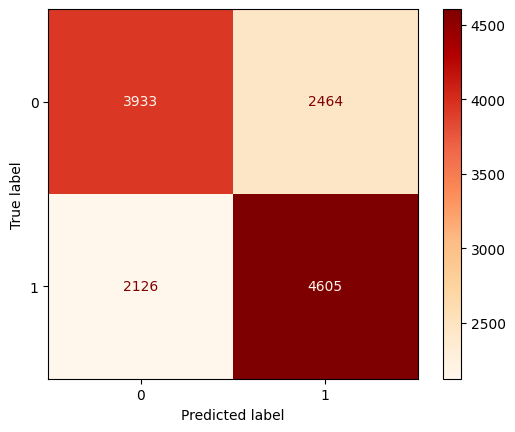

In [414]:
auc_xg = roc_auc_score(y_pred_xg, y_test)
acc_xg = accuracy_score(y_pred_xg, y_test)

print('AUC Score:', auc_xg.round(5))
print('Accuracy Score:', acc_xg.round(5))

# Assuming you have true labels in 'y_true' and predicted labels in 'y_pred'
cm = confusion_matrix(y_test, y_pred_xg)

# Create the ConfusionMatrixDisplay
cm_display = ConfusionMatrixDisplay(cm)

# Set the colormap to red and orange
cmap = plt.cm.get_cmap('OrRd')

# Plot the confusion matrix with the chosen colormap
cm_display.plot(cmap=cmap);

## Evaluating Profit/Loss

We can also look at the predicted probabilities for our test set and see how they compare to Bet365 odds. 

First we create a function to add predicted values and probabilities to our odds_win_test dataframe:

In [423]:
def add_preds_probs(odds_win_df, X_test, model):

    # Make predictions on the test data
    y_pred = model.predict(X_test)

    # Get probabilities
    y_prob = model.predict_proba(X_test)

    # Convert probabilities to odds format
    y_prob = 1/y_prob

    # Get only probability of a win
    y_prob = [prob[1] for prob in y_prob]

    # Add to odds_win_df
    odds_win_df['model_odds'] = y_prob
    odds_win_df['pred_win'] = y_pred

    return odds_win_df

In [424]:
odds_win_df = add_preds_probs(odds_win_test, X_test, xg)

We can define functions for calculating profit/loss in different scenarios:

In [425]:
# Function to calculate returns by betting on favourite:

def returns_from_fav(odds_win_df):
    # Filter the DataFrame for rows where the odds are less than or equal to 2.00
    filtered_df = odds_win_df[odds_win_df['odds'] <= 1.90].copy()

    # Calculate the stake for each bet to ensure winnings are always £1
    filtered_df.loc[:, 'stake'] = 1 / (filtered_df['odds'] - 1)

    # Calculate the returns for each bet
    returns = filtered_df.apply(lambda row: 1 if row['won'] else -row['stake'], axis=1)

    # Calculate the total return and total staked
    total_return = returns.sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total return and total staked
    print(f"Total return from betting on favourite: £{total_return:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

returns_from_fav(odds_win_df)

Total return from betting on favourite: £-1300.19
Total staked: £inf


In [426]:
# Function to calculate returns if we bet on every player the model predicted would win:

def returns_from_model_pred_win(odds_win_df):
    # Filter the DataFrame for rows where the model predicted a win
    filtered_df = odds_win_df[odds_win_df['pred_win'] == 1].copy()

    # Calculate the stake for each bet to ensure winnings are always £1
    filtered_df.loc[:, 'stake'] = 1 / (filtered_df['odds'] - 1)

    # Calculate the returns for each bet
    returns = filtered_df.apply(lambda row: 1 if row['won'] else -row['stake'], axis=1)

    # Calculate the total return and total staked
    total_return = returns.sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total return and total staked
    print(f"Total returns from betting on player model predicted to win: £{total_return:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

returns_from_model_pred_win(odds_win_df)


Total returns from betting on player model predicted to win: £-1239.57
Total staked: £inf


In [427]:
def returns_from_lower_odds(odds_win_df):
    # Filter the DataFrame for rows where the model odds were lower than the bookmaker odds
    filtered_df = odds_win_df[odds_win_df['model_odds'] < odds_win_df['odds']].copy()

    # Calculate the stake for each bet to ensure winnings are always £1
    filtered_df.loc[:, 'stake'] = 1 / (filtered_df['odds'] - 1)

    # Calculate the returns for each bet
    returns = filtered_df.apply(lambda row: 1 if row['won'] else -row['stake'], axis=1)

    # Calculate the total return and total staked
    total_return = returns.sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total return and total staked
    print(f"Total returns from betting on players where model odds are lower than B365: £{total_return:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

returns_from_lower_odds(odds_win_df)


Total returns from betting on players where model odds are lower than B365: £-423.46
Total staked: £4655.12


In [428]:
# Function to calculate returns if we only bet on players where the model's odds 
# were lower than the bookmaker odds and who the model predicted would win:
   
def returns_lower_odds_and_pred_win(odds_win_df):
    # Filter the DataFrame for rows where the model predicted a win and the model odds were lower than the bookmaker odds
    filtered_df = odds_win_df[(odds_win_df['pred_win'] == 1) & (odds_win_df['model_odds'] < odds_win_df['odds'])].copy()

    # Calculate the stake for each bet to ensure winnings are always £1
    filtered_df.loc[:, 'stake'] = 1 / (filtered_df['odds'] - 1)

    # Calculate the returns for each bet
    returns = filtered_df.apply(lambda row: 1 if row['won'] else -row['stake'], axis=1)

    # Calculate the total return and total staked
    total_return = returns.sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total return and total staked
    print(f"Total returns from betting on players where model odds are lower than B365 and model predicted to win: £{total_return:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

returns_lower_odds_and_pred_win(odds_win_df)


Total returns from betting on players where model odds are lower than B365 and model predicted to win: £-307.41
Total staked: £3473.42


In [429]:
# Function to calculate returns if we only bet on players where the model's odds 
# were lower than the bookmaker odds and who the model predicted would lose:
   
def returns_lower_odds_and_pred_lose(odds_win_df):
    # Filter the DataFrame for rows where the model predicted a loss and the model odds were lower than the bookmaker odds
    filtered_df = odds_win_df[(odds_win_df['pred_win'] == 0) & (odds_win_df['model_odds'] < odds_win_df['odds'])].copy()

    # Calculate the stake for each bet to ensure winnings are always £1
    filtered_df.loc[:, 'stake'] = 1 / (filtered_df['odds'] - 1)

    # Calculate the returns for each bet
    returns = filtered_df.apply(lambda row: 1 if row['won'] else -row['stake'], axis=1)

    # Calculate the total return and total staked
    total_return = returns.sum()
    total_staked = filtered_df['stake'].sum()

    # Print the total return and total staked
    print(f"Total returns from betting on players where model odds are lower than B365 and model predicted to lose: £{total_return:.2f}")
    print(f"Total staked: £{total_staked:.2f}")

returns_lower_odds_and_pred_lose(odds_win_df)

Total returns from betting on players where model odds are lower than B365 and model predicted to lose: £-116.06
Total staked: £1181.70


## Evaluating on 2023 Results

First we load the dataset:

In [430]:
df_2023 = pd.read_excel(r'2023_dataset\2023.xlsx')

Then we can run through the same pre-processing steps as before:

In [431]:
# Create winner and loser dataframes
df_winners_2023, df_losers_2023 = create_winner_loser_dfs(df_2023)

In [432]:
# Combine dataframes
match_df_2023 = combine_winners_losers_dfs(df_winners_2023, df_losers_2023) 

In [433]:
# Create prior match features
match_df_2023 = create_prior_match_features(match_df_2023)

In [434]:
# Extract odds data 
odds_win_df_2023 = extract_odds_df(match_df_2023)

In [435]:
# Create prior score features
match_df_2023 = create_prior_score_features(match_df_2023)

In [436]:
# Load model
xg = pickle.load(open('xg_model.pkl', 'rb'))

In [437]:
# Add predictions and probabilities
odds_win_df_2023 = add_preds_probs(odds_win_df_2023, match_df_2023, xg)

We can now look at returns for 2023 matches:

In [438]:
returns_from_fav(odds_win_df_2023)
returns_from_model_pred_win(odds_win_df_2023)
returns_from_lower_odds(odds_win_df_2023)
returns_lower_odds_and_pred_win(odds_win_df_2023)
returns_lower_odds_and_pred_lose(odds_win_df_2023)

Total return from betting on favourite: £13.13
Total staked: £3203.69
Total returns from betting on player model predicted to win: £-5.84
Total staked: £3310.73
Total returns from betting on players where model odds are lower than B365: £-29.52
Total staked: £1010.83
Total returns from betting on players where model odds are lower than B365 and model predicted to win: £-44.10
Total staked: £909.17
Total returns from betting on players where model odds are lower than B365 and model predicted to lose: £14.58
Total staked: £101.66
